In [1]:
from __future__ import print_function
from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from IPython.display import display, HTML

from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn import preprocessing


import warnings
warnings.filterwarnings('ignore')

mkdir -p failed for path /shared/.cache/b00090279/matplotlib: [Errno 13] Permission denied: '/shared/.cache/b00090279'
Matplotlib created a temporary cache directory at /tmp/matplotlib-chydreqo because there was an issue with the default path (/shared/.cache/b00090279/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [5]:
# reading raw data file
har_df = pd.read_csv('./WISDM_ar_v1.1/WISDM_ar_v1.1_raw.csv')

# removing null values
har_df = har_df.dropna()
har_df.shape

(1073623, 6)

In [6]:
# drop the rows where timestamp is 0
df = har_df[har_df['timestamp'] != 0]

# now arrange data in ascending order of the user and timestamp
df = df.sort_values(by = ['user', 'timestamp'], ignore_index=True)

In [7]:
har_df

,user,activity,timestamp,x-axis,y-axis,z-axis
0,1,Walking,4991922345000,0.69,10.80,-2.030000
1,1,Walking,4991972333000,6.85,7.44,-0.500000
2,1,Walking,4992022351000,0.93,5.63,-0.500000
3,1,Walking,4992072339000,-2.11,5.01,-0.690000
4,1,Walking,4992122358000,-4.59,4.29,-1.950000
...,...,...,...,...,...,...
1073618,36,Standing,15049012250000,-0.91,9.43,2.533385
1073619,36,Standing,15049062268000,-1.18,9.51,2.492524
1073620,36,Standing,15049112287000,-1.50,9.53,2.533385
1073621,36,Standing,15049162275000,-2.07,8.77,2.179256


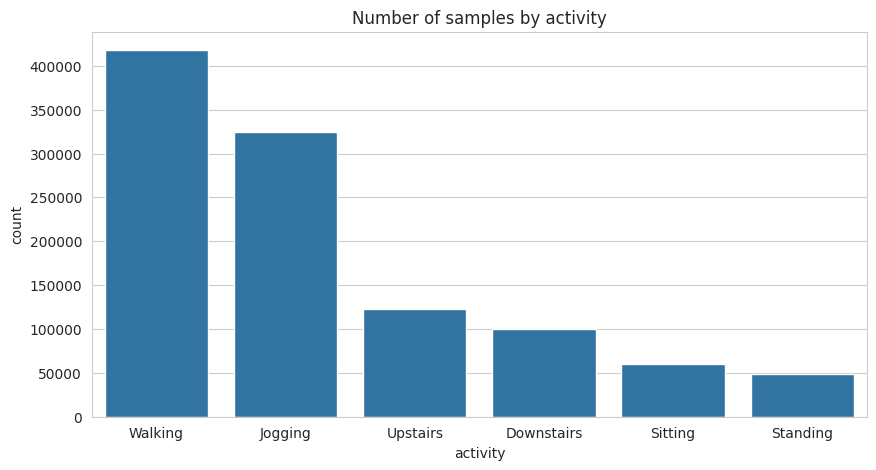

In [8]:
sns.set_style('whitegrid')
plt.figure(figsize = (10, 5))
sns.countplot(x = 'activity', data = df)
plt.title('Number of samples by activity')
plt.show()

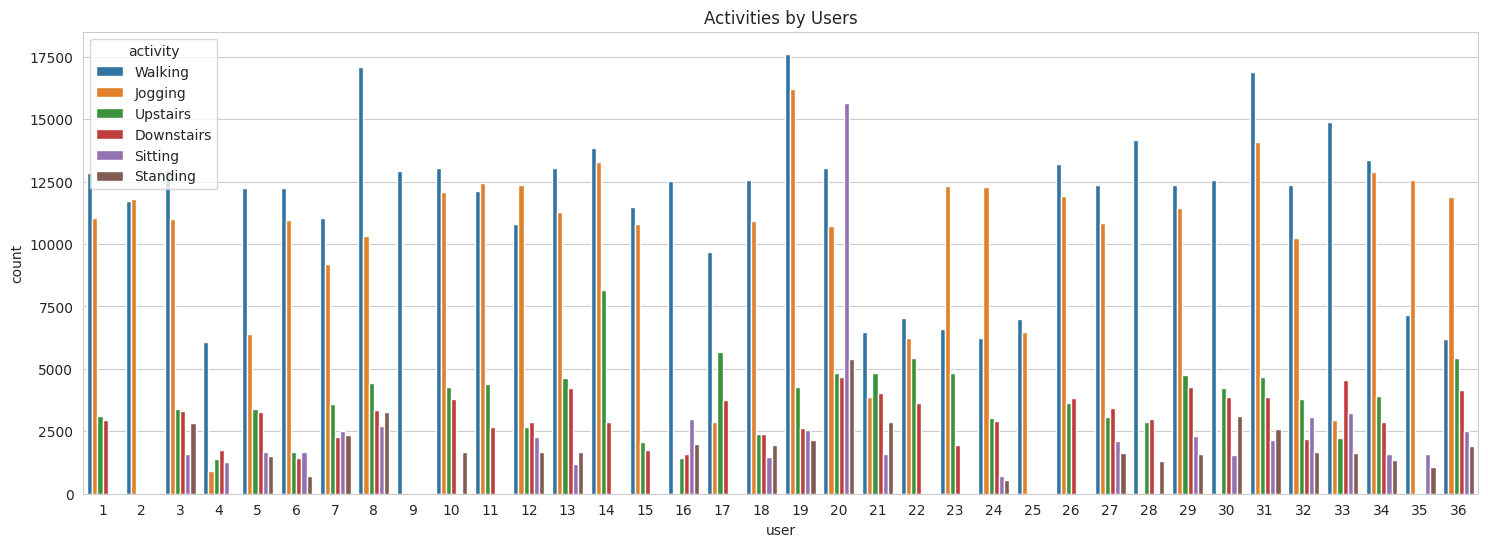

In [9]:
plt.figure(figsize = (18, 6))
sns.countplot(x = 'user', hue = 'activity', data = df)
plt.title('Activities by Users')
plt.show()

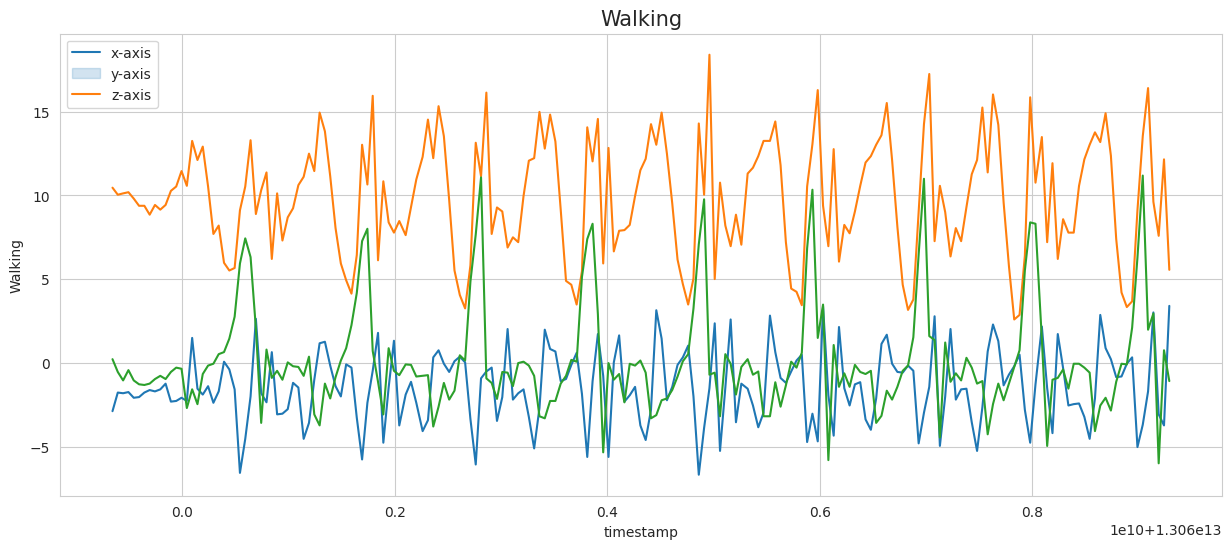

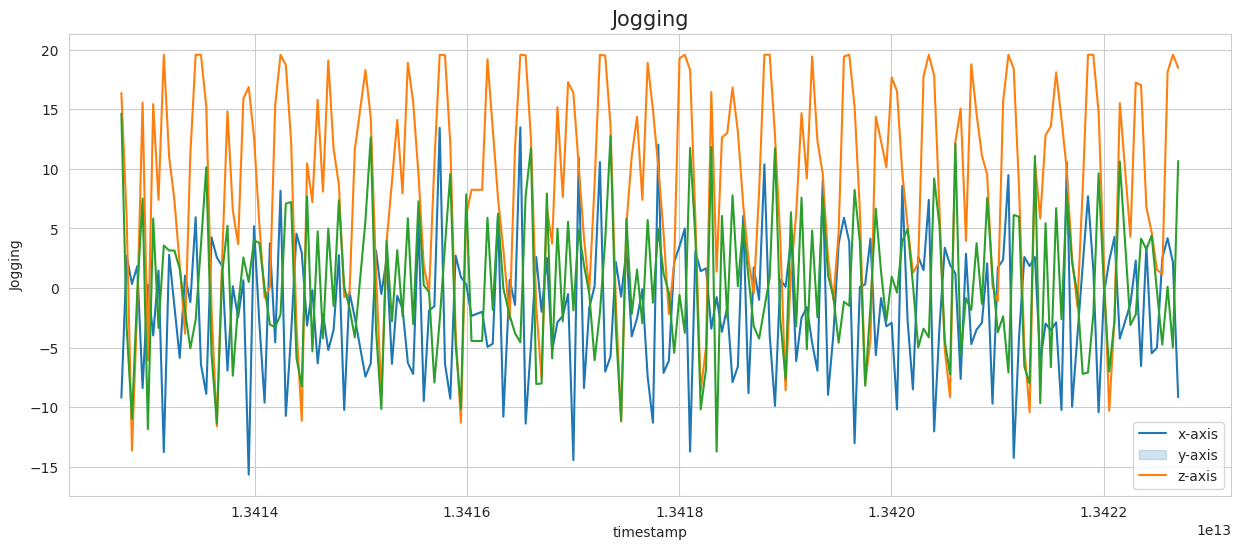

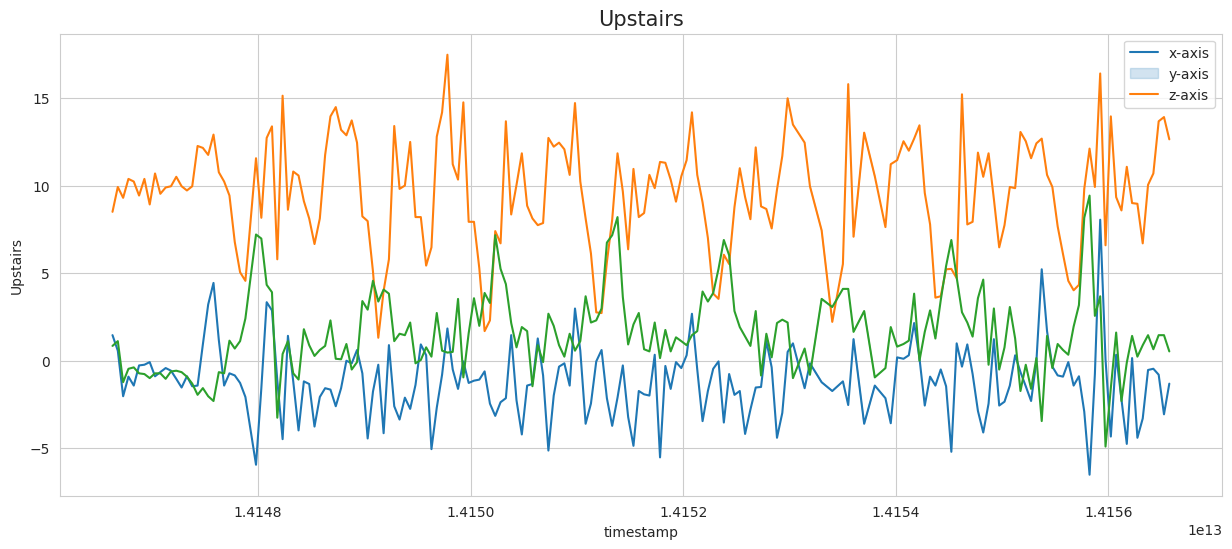

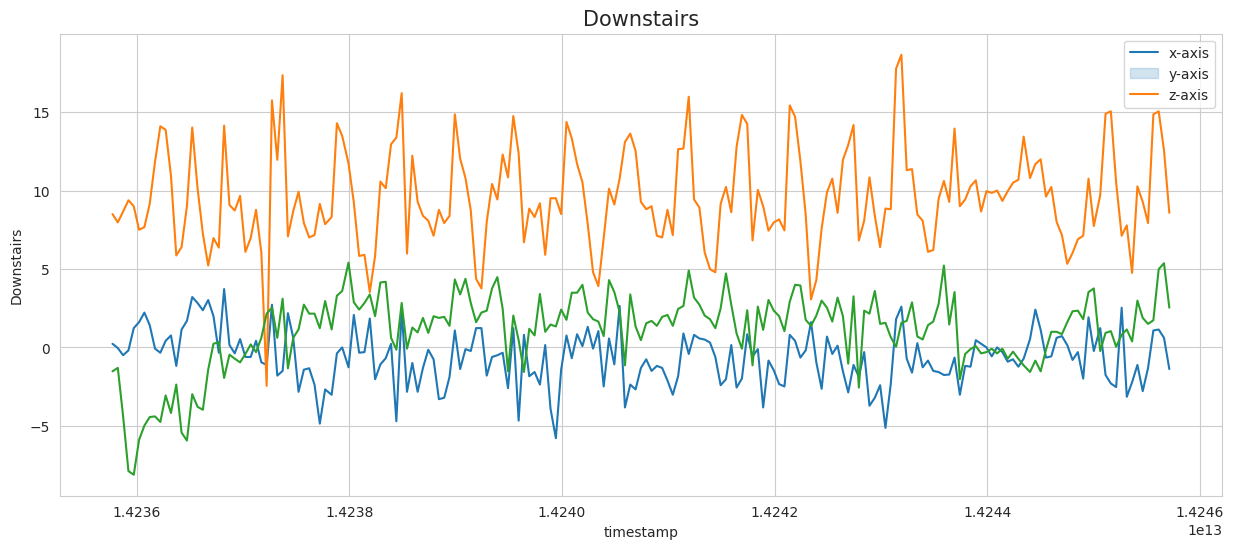

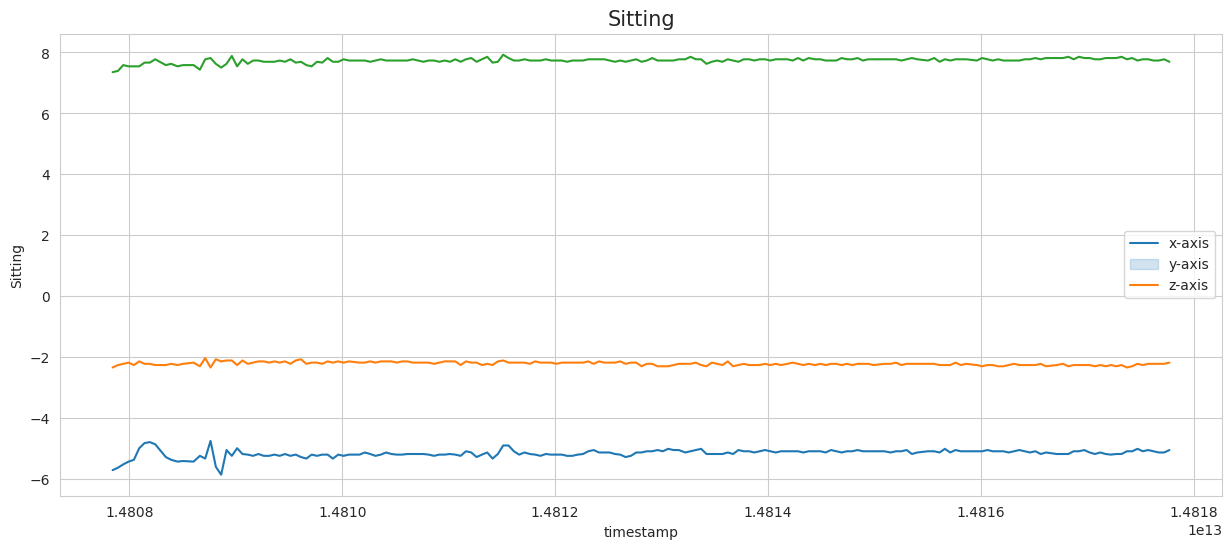

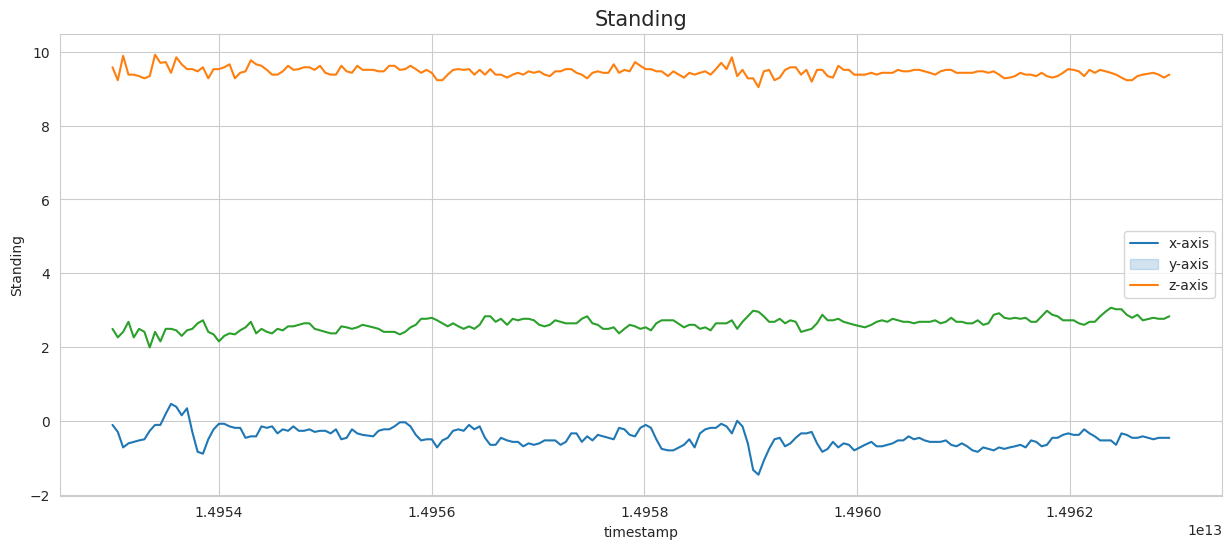

In [10]:
for i in ['Walking', 'Jogging', 'Upstairs', 'Downstairs', 'Sitting', 'Standing']:
  data_36 = df[(df['user'] == 36) & (df['activity'] == i)][:200]
  plt.figure(figsize = (15, 6))
  sns.lineplot(y = 'x-axis', x = 'timestamp', data = data_36)
  sns.lineplot(y = 'y-axis', x = 'timestamp', data = data_36)
  sns.lineplot(y = 'z-axis', x = 'timestamp', data = data_36)
  plt.legend(['x-axis', 'y-axis', 'z-axis'])
  plt.ylabel(i)
  plt.title(i, fontsize = 15)
  plt.show()

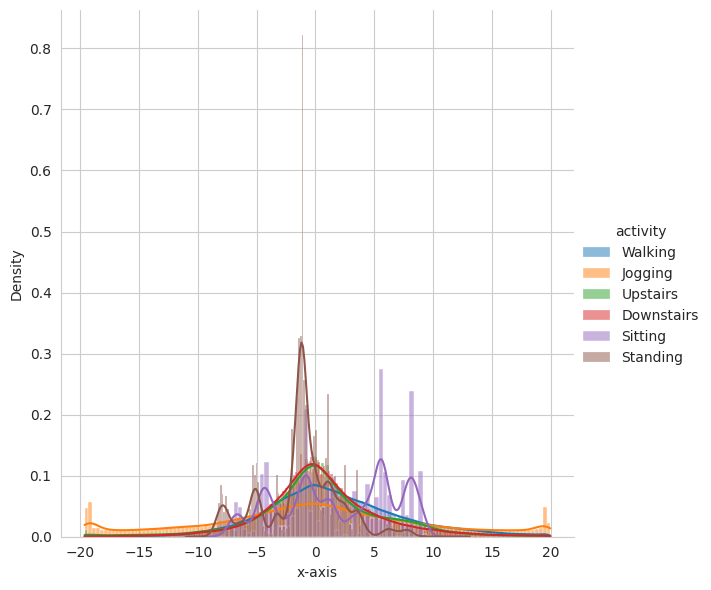

In [13]:
sns.FacetGrid(df, hue='activity', height=6).map(sns.histplot, 'x-axis', kde=True, stat='density').add_legend()

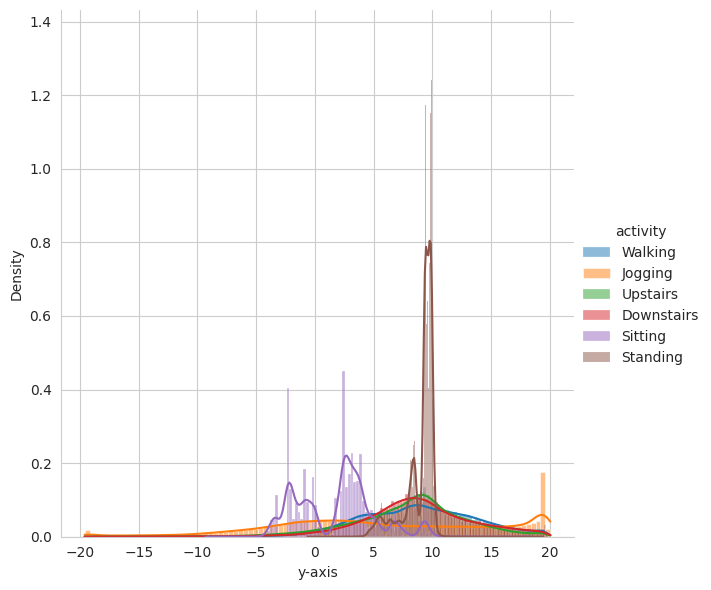

In [14]:
sns.FacetGrid(df, hue='activity', height=6).map(sns.histplot, 'y-axis', kde=True, stat='density').add_legend()

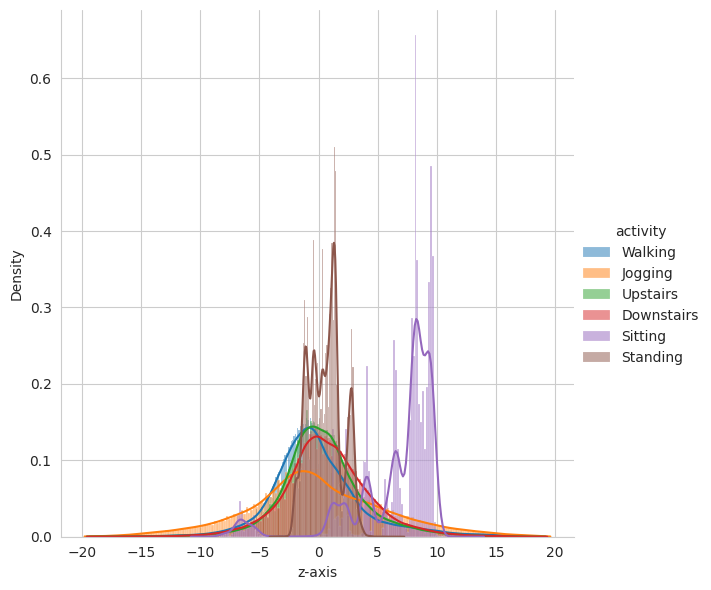

In [15]:
sns.FacetGrid(df, hue='activity', height=6).map(sns.histplot, 'z-axis', kde=True, stat='density').add_legend()

In [16]:
# Define column name of the label vector
LABEL = 'ActivityEncoded'
# Transform the labels from String to Integer via LabelEncoder
le = preprocessing.LabelEncoder()
# Add a new column to the existing DataFrame with the encoded values
df[LABEL] = le.fit_transform(df['activity'].values.ravel())

In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 假设您的数据集如下
# df = pd.DataFrame({'x': [1, 2, 3], 'y': [4, 5, 6], 'z': [7, 8, 9]})

# 初始化StandardScaler
scaler = StandardScaler()

# 选择需要标准化的列
columns_to_scale = ['x-axis', 'y-axis', 'z-axis']

# 使用fit_transform标准化数据
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# 查看标准化后的数据
print(df)


         user  activity       timestamp    x-axis    y-axis    z-axis  \
0           1   Walking   4991922345000  0.002594  0.514975 -0.507894   
1           1   Walking   4991972333000  0.893168  0.015937 -0.188432   
2           1   Walking   4992022351000  0.037292 -0.252891 -0.188432   
3           1   Walking   4992072339000 -0.402212 -0.344975 -0.228104   
4           1   Walking   4992122358000 -0.760755 -0.451912 -0.491190   
...       ...       ...             ...       ...       ...       ...   
1073618    36  Standing  15049012250000 -0.228724  0.311498  0.444935   
1073619    36  Standing  15049062268000 -0.267759  0.323380  0.436404   
1073620    36  Standing  15049112287000 -0.314022  0.326350  0.444935   
1073621    36  Standing  15049162275000 -0.396429  0.213473  0.370994   
1073622    36  Standing  15049212262000 -0.406549  0.379819  0.595663   

         ActivityEncoded  
0                      5  
1                      5  
2                      5  
3              

In [18]:
# # The number of steps within one time segment
# TIME_PERIODS = 100
# # The steps to take from one segment to the next; if this value is equal to
# # TIME_PERIODS, then there is no overlap between the segments
# STEP_DISTANCE = 50
# The number of steps within one time segment
TIME_PERIODS = 100
# The steps to take from one segment to the next; if this value is equal to
# TIME_PERIODS, then there is no overlap between the segments
STEP_DISTANCE = 50

In [21]:
from scipy.stats import moment

# x, y, z acceleration as features
N_FEATURES = 3

def create_segments_and_labels(df, time_steps, step, label_name):
    # Number of steps to advance in each iteration (for me, it should always
    # be equal to the time_steps in order to have no overlap between segments)
    # step = time_steps
    segments = []
    labels = []
    users =[]
    for i in range(0, len(df) - time_steps, step):
        xs = df['x-axis'].values[i: i + time_steps]
        ys = df['y-axis'].values[i: i + time_steps]
        zs = df['z-axis'].values[i: i + time_steps]
        # Retrieve the most often used label in this segment
        label = stats.mode(df[label_name].iloc[i:i+time_steps], keepdims=True).mode[0]
        segments.append([xs, ys, zs])
        labels.append(label)
        user  = stats.mode(df['user'].iloc[i:i+time_steps], keepdims=True).mode[0]
        users.append(user-1)

    # Bring the segments into a better shape
    reshaped_segments = np.asarray(segments, dtype= np.float32).reshape(-1, time_steps, N_FEATURES)
    labels = np.asarray(labels)
    users = np.asarray(users)

    return reshaped_segments, labels, users

x, y, y_users = create_segments_and_labels(df,
                                          TIME_PERIODS,
                                          STEP_DISTANCE,
                                          LABEL)

In [22]:
LABELS = ['Downstairs',
          'Jogging',
          'Sitting',
          'Standing',
          'Upstairs',
          'Walking']
print(LABELS)
print(le.transform(LABELS))

['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']
[0 1 2 3 4 5]


In [24]:
from tensorflow.keras.utils import to_categorical

Y_one_hot       = to_categorical(y)
Y_one_hot_users = to_categorical(y_users)

In [25]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train_one_hot, y_test_one_hot = train_test_split(x, Y_one_hot, test_size=0.33, random_state=42)

In [27]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Reshape, Conv1D, MaxPooling1D
from tensorflow.keras.utils import to_categorical

In [28]:
model = models.Sequential()
model.add(layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(100, 3)))
model.add(layers.Dropout(0.3))
model.add(layers.Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(layers.Dropout(0.3))
# model.add(layers.Conv1D(filters=64, kernel_size=3, activation='relu'))
# model.add(layers.Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(layers.LSTM(units=100, return_sequences=True))
# model.add(layers.LSTM(units=100))
model.add(layers.Flatten())
model.add(layers.Dropout(0.3))
#model.add(layers.Dense(units=100, activation='relu'))
model.add(layers.Dense(units=6, activation='softmax'))


2026-03-03 10:13:36.771545: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-03 10:13:36.794432: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-03 10:13:36.797480: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [29]:
model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [30]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 98, 32)            320       
                                                                 
 dropout (Dropout)           (None, 98, 32)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 96, 64)            6208      
                                                                 
 dropout_1 (Dropout)         (None, 96, 64)            0         
                                                                 
 lstm (LSTM)                 (None, 96, 100)           66000     
                                                                 
 flatten (Flatten)           (None, 9600)              0         
                                                                 
 dropout_2 (Dropout)         (None, 9600)              0

In [96]:
#history = model.fit(x_train, y_train_one_hot, validation_data=(x_test, y_test_one_hot), epochs=30, batch_size=64)
history = model.fit(x_train, y_train_one_hot, epochs=50, batch_size=64, validation_data=(x_test, y_test_one_hot), callbacks=[
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
])

Epoch 1/50
225/225 [==============================] - 5s 22ms/step - loss: 0.0144 - accuracy: 0.9947 - val_loss: 0.0705 - val_accuracy: 0.9822
Epoch 2/50
225/225 [==============================] - 4s 19ms/step - loss: 0.0152 - accuracy: 0.9940 - val_loss: 0.0721 - val_accuracy: 0.9819
Epoch 3/50
225/225 [==============================] - 4s 20ms/step - loss: 0.0140 - accuracy: 0.9951 - val_loss: 0.0717 - val_accuracy: 0.9818
Epoch 4/50
225/225 [==============================] - 4s 19ms/step - loss: 0.0139 - accuracy: 0.9955 - val_loss: 0.0703 - val_accuracy: 0.9824
Epoch 5/50
225/225 [==============================] - 4s 20ms/step - loss: 0.0125 - accuracy: 0.9956 - val_loss: 0.0705 - val_accuracy: 0.9822
Epoch 6/50
225/225 [==============================] - 5s 21ms/step - loss: 0.0138 - accuracy: 0.9949 - val_loss: 0.0701 - val_accuracy: 0.9825
Epoch 7/50
225/225 [==============================] - 5s 22ms/step - loss: 0.0126 - accuracy: 0.9955 - val_loss: 0.0710 - val_accuracy: 0.9824

In [1]:
# 评估模型
loss, accuracy = model.evaluate(x_test, y_test_one_hot)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

# 绘制训练过程中的损失和准确率曲线
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

NameError: name 'model' is not defined

In [113]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support

# 使用 predict 方法获取预测概率
y_pred_prob = model.predict(x_test)

# 使用 argmax 获取预测的类标签
y_pred = y_pred_prob.argmax(axis=-1)

# 检查 y_test 的格式
if len(y_test_one_hot.shape) > 1:  # 如果是 one-hot 编码
    y_test = y_test_one_hot.argmax(axis=-1)  # 转换为类标签
else:
    y_test = y_test_one_hot  # 如果已经是类标签，直接赋值

# 确保 y_pred 和 y_test 是一维数组
y_pred = y_pred.flatten()
y_test = y_test.flatten()

# 创建混淆矩阵
cm = confusion_matrix(y_test, y_pred)

# 计算准确率、精确率、召回率和 F1 分数
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9823595822749083
Confusion Matrix:
 [[ 655    1    1    0   23    6]
 [   2 2132    0    0   14    8]
 [   0    0  375    2    0    0]
 [   0    0    2  321    0    0]
 [  28    8    2    0  760   13]
 [   3    4    0    0    8 2718]]
Precision: 0.9823386065919107
Recall: 0.9823595822749083
F1 Score: 0.9823427772597836


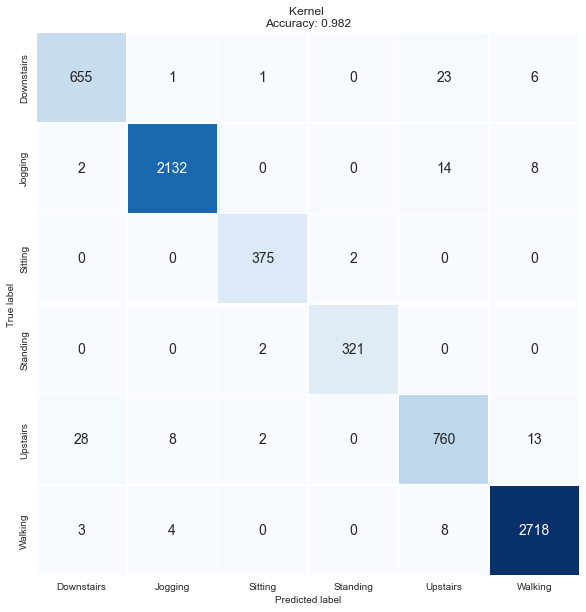

In [114]:
# 使用 predict 方法获取预测概率
y_pred_prob = model.predict(x_test)

# 使用 argmax 获取预测的类标签
y_pred = y_pred_prob.argmax(axis=-1)

# 将 y_test_one_hot 转换为类标签
y_test = y_test_one_hot.argmax(axis=-1)

# 创建混淆矩阵
cm = confusion_matrix(y_test, y_pred) 

# 将混淆矩阵转换为 DataFrame 以便于绘图
cm_df = pd.DataFrame(cm,
                     index=['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking'], 
                     columns=['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking'])

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)

# 绘制热图
plt.figure(figsize=(10, 10))
sns.heatmap(cm_df, annot=True, fmt="d", linewidths=0.5, cmap='Blues', cbar=False, annot_kws={'size': 14}, square=True)
plt.title('Kernel \nAccuracy: {0:.3f}'.format(accuracy))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [100]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']))

              precision    recall  f1-score   support

  Downstairs       0.95      0.95      0.95       686
     Jogging       0.99      0.99      0.99      2156
     Sitting       0.99      0.99      0.99       377
    Standing       0.99      0.99      0.99       323
    Upstairs       0.94      0.94      0.94       811
     Walking       0.99      0.99      0.99      2733

    accuracy                           0.98      7086
   macro avg       0.98      0.98      0.98      7086
weighted avg       0.98      0.98      0.98      7086



In [101]:
import os

In [102]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\34539\AppData\Local\Temp\tmpauhutctm\assets


INFO:tensorflow:Assets written to: C:\Users\34539\AppData\Local\Temp\tmpauhutctm\assets


In [103]:
# 保存量化后的模型
model_path = 'test.tflite'
with open(model_path, 'wb') as f:
    f.write(tflite_model)

# 查看量化后的模型大小
model_size = os.path.getsize(model_path)
print(f'TFLite 模型大小: {model_size / 1024:.2f} KB')

TFLite 模型大小: 513.23 KB


In [104]:
batch_size = 1
model.input.set_shape((batch_size,) + model.input.shape[1:])
model.summary()

Model: "sequential_10"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_19 (Conv1D)           (None, 98, 32)            320       
_________________________________________________________________
dropout_13 (Dropout)         (None, 98, 32)            0         
_________________________________________________________________
conv1d_20 (Conv1D)           (None, 96, 64)            6208      
_________________________________________________________________
dropout_14 (Dropout)         (None, 96, 64)            0         
_________________________________________________________________
lstm_12 (LSTM)               (None, 96, 100)           66000     
_________________________________________________________________
flatten_8 (Flatten)          (None, 9600)              0         
_________________________________________________________________
dropout_15 (Dropout)         (None, 9600)            

In [105]:
# 定义代表性数据集生成器函数
def representative_dataset_gen():
    for input_value in tf.data.Dataset.from_tensor_slices(x_test).batch(1).take(100):
        yield [input_value]
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.experimental_new_quantizer = True
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
tflite_model_quant = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\34539\AppData\Local\Temp\tmpn0wz0h_s\assets


INFO:tensorflow:Assets written to: C:\Users\34539\AppData\Local\Temp\tmpn0wz0h_s\assets


In [106]:
interpreter = tf.lite.Interpreter(model_content=tflite_model_quant)
input_type = interpreter.get_input_details()[0]['dtype']

output_type = interpreter.get_output_details()[0]['dtype']
input_type,output_type

(numpy.float32, numpy.float32)

In [107]:
# 保存量化后的模型
model_path = 'test1.tflite'
with open(model_path, 'wb') as f:
    f.write(tflite_model_quant)

# 查看量化后的模型大小
model_size = os.path.getsize(model_path)
print(f'TFLite 模型大小: {model_size / 1024:.2f} KB')

TFLite 模型大小: 136.77 KB


In [108]:
# 定义代表性数据集生成器函数
def representative_dataset_gen():
    for input_value in tf.data.Dataset.from_tensor_slices(x_test).batch(1).take(100):
        yield [input_value]
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8  # 或者 tf.uint8
converter.inference_output_type = tf.int8  # 或者 tf.uint8
tflite_model_quant = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\34539\AppData\Local\Temp\tmpz1u9_94s\assets


INFO:tensorflow:Assets written to: C:\Users\34539\AppData\Local\Temp\tmpz1u9_94s\assets


In [109]:
tflite_model_quant = converter.convert()
interpreter = tf.lite.Interpreter(model_content=tflite_model_quant)
input_type = interpreter.get_input_details()[0]['dtype']

output_type = interpreter.get_output_details()[0]['dtype']
input_type, output_type

INFO:tensorflow:Assets written to: C:\Users\34539\AppData\Local\Temp\tmp0a1fybux\assets


INFO:tensorflow:Assets written to: C:\Users\34539\AppData\Local\Temp\tmp0a1fybux\assets


(numpy.int8, numpy.int8)

In [110]:
# 保存量化后的模型
model_path = 'test2.tflite'
with open(model_path, 'wb') as f:
    f.write(tflite_model_quant)

# 查看量化后的模型大小
model_size = os.path.getsize(model_path)
print(f'TFLite 模型大小: {model_size / 1024:.2f} KB')

TFLite 模型大小: 136.51 KB


In [93]:
# 加载量化后的 TFLite 模型
model_path = 'test2.tflite'
interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()

# 获取输入和输出张量的信息
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 量化输入数据
def quantize_input(input_data, input_scale, input_zero_point):
    return (input_data / input_scale + input_zero_point).astype(np.int8)

# 获取量化参数
input_scale, input_zero_point = input_details[0]['quantization']

# 预测函数
def predict(interpreter, input_data):
    input_data_quant = quantize_input(input_data, input_scale, input_zero_point)
    interpreter.set_tensor(input_details[0]['index'], input_data_quant)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return output_data

# 评估模型性能
correct_predictions = 0
total_predictions = len(x_test)

for i in range(total_predictions):
    input_data = np.expand_dims(x_test[i], axis=0)  # 扩展维度以匹配模型输入
    predictions = predict(interpreter, input_data)
    predicted_label = np.argmax(predictions)
    
    true_label = np.argmax(y_test_one_hot[i])  # 将独热编码转换为标签索引

    if predicted_label == true_label:
        correct_predictions += 1

accuracy = correct_predictions / total_predictions
print(f'量化后的 TFLite 模型准确率: {accuracy:.4f}')

量化后的 TFLite 模型准确率: 0.9709


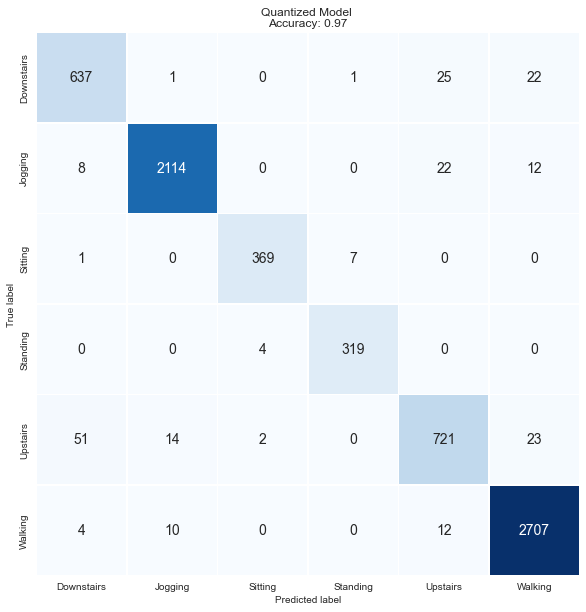

In [111]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

# 量化后的 TFLite 模型路径
model_path = 'test2.tflite'
interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()

# 获取输入和输出张量的信息
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 量化输入数据的函数
def quantize_input(input_data, input_scale, input_zero_point):
    return (input_data / input_scale + input_zero_point).astype(np.int8)

# 获取量化参数
input_scale, input_zero_point = input_details[0]['quantization']

# 预测函数
def predict(interpreter, input_data):
    input_data_quant = quantize_input(input_data, input_scale, input_zero_point)
    interpreter.set_tensor(input_details[0]['index'], input_data_quant)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return output_data

# 用于存储预测结果和真实标签
y_true = []
y_pred = []

# 评估模型性能并收集预测结果
total_predictions = len(x_test)

for i in range(total_predictions):
    input_data = np.expand_dims(x_test[i], axis=0)  # 扩展维度以匹配模型输入
    predictions = predict(interpreter, input_data)
    predicted_label = np.argmax(predictions)
    
    true_label = np.argmax(y_test_one_hot[i])  # 将独热编码转换为标签索引

    y_true.append(true_label)
    y_pred.append(predicted_label)

# 创建混淆矩阵
cm = confusion_matrix(y_true, y_pred)

# 将混淆矩阵转换为 DataFrame 以便于绘图
cm_df = pd.DataFrame(cm,
                     index=['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking'], 
                     columns=['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking'])

# 计算准确率
accuracy = accuracy_score(y_true, y_pred)

# 绘制热图
plt.figure(figsize=(10, 10))
sns.heatmap(cm_df, annot=True, fmt="d", linewidths=0.5, cmap='Blues', cbar=False, annot_kws={'size': 14}, square=True)
plt.title('Quantized Model \nAccuracy: {0:.2f}'.format(accuracy))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()
